# TradeTrack Analytics
## AI-Powered Trading Performance & Risk Analysis

**End-to-end analysis of 10,000+ trades across 12 traders, 6 instruments and 7 strategies.**

This notebook is the analytical narrative of the project. It loads the raw trade
blotter, profiles and repairs its data-quality problems, engineers the features
that make trading performance measurable, computes the risk and return metrics a
desk actually reports, visualises the findings, and finishes with a
leakage-controlled machine-learning model.

---

### Contents

| # | Section |
|---|---|
| 1 | Setup and data load |
| 2 | Data quality assessment |
| 3 | Cleaning pipeline |
| 4 | Feature engineering |
| 5 | KPI and risk metrics |
| 6 | Visual analysis |
| 7 | Trading psychology |
| 8 | Machine learning |
| 9 | Export and conclusions |

### A note on methodology

Two conventions run through the whole analysis and are worth stating up front:

1. **All performance is measured net of fees.** Gross P&L flatters every
   strategy; on this dataset fees consume more than half of the gross result, so
   any conclusion drawn from gross numbers would be wrong.
2. **Comparisons use R-multiples, not dollars.** One R is the amount risked on
   that trade (`|entry − stop| × quantity`). Expressing outcomes in R makes a
   \$12 scalp and a \$4,000 swing directly comparable, and stops the analysis
   from simply rediscovering who traded the biggest size.

## 1. Setup and data load

In [1]:
import os, sys, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)

# Project modules live in ../python
sys.path.insert(0, os.path.abspath(os.path.join("..", "python")))

import viz_theme as T
from config import RAW_TRADES_CSV, CLEAN_TRADES_CSV, TRADERS

T.apply_theme()                       # shared dark fintech chart theme
pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

STARTING_CAPITAL = float(sum(t["start_balance"] for t in TRADERS))
print(f"pandas {pd.__version__} | numpy {np.__version__}")
print(f"Combined opening capital: ${STARTING_CAPITAL:,.0f}")

pandas 2.3.3 | numpy 2.0.2
Combined opening capital: $430,000


In [2]:
raw = pd.read_csv(RAW_TRADES_CSV, dtype=str)
print(f"Raw blotter: {raw.shape[0]:,} rows x {raw.shape[1]} columns")
raw.head(5)

Raw blotter: 11,130 rows x 29 columns


,trade_id,trader_id,trader_name,trade_date,entry_time,exit_time,exit_date,trading_session,asset,asset_class,trade_type,strategy,entry_price,exit_price,stop_loss,take_profit,quantity,risk_pct,reward_pct,profit_loss,fees,net_profit,trade_duration_min,win_loss,account_balance,max_drawdown_pct,risk_reward_ratio,emotional_state,trade_notes
0,TT-004670,TR-002,M. Chen,2024-11-21,06:44:54,06:47:54,2024-11-21,Asia,US30,Index,Sell,Scalping,46017.00617,45871.5981,46161.82624,45886.66811,1.010356,0.577,0.519,146.91,9.3,137.61,3.0,Win,25491.92,44.888,0.9,Disciplined,"A+ setup. Risk sized correctly, no interferenc..."
1,TT-008310,TR-003,S. Iyer,2025-10-03,02:47:13,04:47:13,2025-10-03,Asia,EURUSD,Forex,Sell,Trend Following,0.84581,0.8481,0.8481,0.83985,32108.34209,1.117,2.916,-73.38,3.26,-76.64,120.0,Loss,6490.9,76.332,2.61,Confident,"Overconfident after a winning run, skipped con..."
2,TT-001584,TR-010,P. Silva,2024-04-11,06:52:52,07:59:52,2024-04-11,Asia,NASDAQ,Index,Buy,Trend Following,17581.41302,17523.17985,17404.43812,18055.70576,0.808577,1.922,5.15,-47.09,3.13,-50.22,67.0,Loss,7395.76,43.286,2.68,Anxious,Second-guessed the entry and exited into noise.
3,TT-009808,TR-012,T. Bergman,2026-03-10,10:02:10,16:06:10,2026-03-10,London,BTC,Crypto,Sell,Trend Following,22854.06758,24056.63485,24056.63485,19919.80344,0.114728,1.2,2.927,-137.97,1.97,-139.94,364.0,Loss,11361.05,74.863,2.44,Neutral,"Choppy conditions on BTC, no follow-through."
4,TT-008169,TR-004,J. Okafor,2025-09-17,09:57:39,10:11:39,2025-09-17,London,ETH,Crypto,Sell,News Trading,1579.6543,1383.16291,1636.61844,1383.12802,50.927208,1.489,5.137,10006.76,68.38,9938.38,14.0,Win,204774.44,18.669,3.45,Greedy,NaN


The raw export is what a real journal application would hand over: everything is
typed as text, and the file carries the usual production defects. The next
section quantifies them before anything is changed.

## 2. Data quality assessment

In [3]:
quality = pd.DataFrame({
    "dtype": raw.dtypes.astype(str),
    "nulls": raw.isna().sum(),
    "null_%": (raw.isna().mean() * 100).round(2),
    "unique": raw.nunique(),
})
quality[quality["nulls"] > 0].sort_values("nulls", ascending=False)

,dtype,nulls,null_%,unique
trade_notes,object,406,3.6500,108
emotional_state,object,262,2.3500,7
exit_time,object,145,1.3000,10113
exit_date,object,145,1.3000,890
exit_price,object,145,1.3000,10755
profit_loss,object,145,1.3000,10453
net_profit,object,145,1.3000,10469
trade_duration_min,object,145,1.3000,1372
win_loss,object,145,1.3000,2


In [4]:
# --- the five defects worth quantifying before cleaning -------------------
exact_dupes = int(raw.duplicated().sum())
id_dupes    = int(raw.duplicated(subset=["trade_id"]).sum())

# Numbers exported with thousands separators, e.g. "1,250.75"
str_numeric = int(raw["entry_price"].astype(str).str.contains(",", na=False).sum() +
                  raw["net_profit"].astype(str).str.contains(",", na=False).sum())

# Categorical values outside their canonical domain (casing / whitespace noise)
canonical_assets = {"BTC", "ETH", "GOLD", "NASDAQ", "US30", "EURUSD"}
casing_noise = int((~raw["asset"].str.strip().str.upper()
                    .isin(canonical_assets)).sum()
                   + (raw["asset"] != raw["asset"].str.strip()).sum())

# Physically impossible durations
dur = pd.to_numeric(raw["trade_duration_min"], errors="coerce")
bad_duration = int((dur <= 0).sum())

open_trades = int(raw["exit_price"].isna().sum())

print(f"Exact duplicate rows        : {exact_dupes:,}")
print(f"Repeated trade_id           : {id_dupes:,}")
print(f"Thousands-separated numbers : {str_numeric:,}")
print(f"Casing / whitespace noise   : {casing_noise:,}")
print(f"Impossible durations (<= 0) : {bad_duration:,}")
print(f"Still-open trades (no exit) : {open_trades:,}")

Exact duplicate rows        : 180
Repeated trade_id           : 180
Thousands-separated numbers : 161
Casing / whitespace noise   : 52
Impossible durations (<= 0) : 48
Still-open trades (no exit) : 145


Each of these needs a *decision*, not just a fix:

| Defect | Decision | Why |
|---|---|---|
| Duplicate rows | drop, keep first | double-submits from the journal UI; keeping them double-counts P&L |
| String-formatted numbers | strip separators, cast | otherwise the whole column silently becomes `object` and every aggregation fails |
| Casing / whitespace | map to a canonical domain | `"btc"`, `" BTC "` and `"BTC"` must not become three instruments |
| Impossible duration | recompute from timestamps | the entry/exit timestamps are the source of truth |
| Fat-finger prices | flag and exclude | a 10× price is not recoverable, and imputing it would invent data |
| Open trades | quarantine, don't drop | they are valid rows, just not *closed* — including them would understate the win rate |

A note on the last two. Dropping a row is a real decision with a cost, so the
pipeline keeps a count of everything it removes and writes it to
`reports/data_quality_report.md`. Silent row loss is the most common way an
analysis quietly becomes wrong.

## 3. Cleaning pipeline

The production implementation lives in `python/data_cleaning.py`. The key steps
are reproduced here so the logic is visible rather than hidden behind an import.

In [5]:
df = raw.copy()

# --- 3.1 deduplicate -----------------------------------------------------
before = len(df)
df = df.drop_duplicates().drop_duplicates(subset=["trade_id"], keep="first")
print(f"3.1 removed {before - len(df):,} duplicate rows")

# --- 3.2 numeric coercion ------------------------------------------------
NUMERIC = ["entry_price", "exit_price", "stop_loss", "take_profit", "quantity",
           "risk_pct", "reward_pct", "profit_loss", "fees", "net_profit",
           "trade_duration_min", "account_balance", "risk_reward_ratio"]
for c in NUMERIC:
    df[c] = pd.to_numeric(
        df[c].astype(str).str.replace(r"[,\s$]", "", regex=True)
             .replace({"nan": np.nan, "None": np.nan, "": np.nan}),
        errors="coerce")
print(f"3.2 coerced {len(NUMERIC)} columns to numeric")

# --- 3.3 canonical categoricals -----------------------------------------
# Driving the map off the known domain protects labels containing acronyms or
# punctuation -- a naive .str.title() turns "FOMO" into "Fomo" and
# "Order Block (SMC)" into "Order Block (Smc)".
DOMAINS = {
    "asset": ["BTC", "ETH", "GOLD", "NASDAQ", "US30", "EURUSD"],
    "trade_type": ["Buy", "Sell"],
    "trading_session": ["Asia", "London", "New York"],
    "strategy": ["Breakout", "Trend Following", "Mean Reversion", "Scalping",
                 "News Trading", "Swing", "Order Block (SMC)"],
    "emotional_state": ["Disciplined", "Confident", "Neutral", "Anxious",
                        "FOMO", "Greedy", "Revenge"],
}
for col, domain in DOMAINS.items():
    lookup = {v.upper(): v for v in domain}
    s = df[col].astype(str).str.strip()
    df[col] = s.str.upper().map(lookup).fillna(s).replace({"NAN": np.nan})
print("3.3 categoricals mapped to canonical domains")

# --- 3.4 timestamps and duration repair ---------------------------------
df["trade_date"] = pd.to_datetime(df["trade_date"], errors="coerce")
df["entry_datetime"] = pd.to_datetime(
    df["trade_date"].dt.strftime("%Y-%m-%d") + " " + df["entry_time"], errors="coerce")
df["exit_datetime"] = pd.to_datetime(
    pd.to_datetime(df["exit_date"], errors="coerce").dt.strftime("%Y-%m-%d")
    + " " + df["exit_time"].astype(str), errors="coerce")

recomputed = (df["exit_datetime"] - df["entry_datetime"]).dt.total_seconds() / 60
df["trade_duration_min"] = np.where(recomputed > 0, recomputed, df["trade_duration_min"])
df.loc[df["trade_duration_min"] <= 0, "trade_duration_min"] = np.nan
print("3.4 durations recomputed from timestamps")

3.1 removed 180 duplicate rows


3.2 coerced 13 columns to numeric
3.3 categoricals mapped to canonical domains
3.4 durations recomputed from timestamps


In [6]:
# --- 3.5 outliers: robust MAD z-score on log price, per instrument -------
# A mean/std z-score is the wrong tool here: the contaminating values are
# exactly the extremes that inflate a standard deviation and then hide inside
# their own inflated threshold. Median absolute deviation is resistant to that.
df["price_outlier"] = False
for asset, grp in df.groupby("asset"):
    lp = np.log(pd.to_numeric(grp["entry_price"], errors="coerce").where(lambda s: s > 0))
    med, mad = lp.median(), (lp - lp.median()).abs().median()
    if np.isfinite(mad) and mad > 0:
        df.loc[grp.index, "price_outlier"] = (0.6745 * (lp - med) / mad).abs() > 8

# --- 3.6 structural invariant: stop and target on the correct side ------
long = df["trade_type"].eq("Buy")
side_ok = np.where(long,
                   (df["stop_loss"] < df["entry_price"]) & (df["take_profit"] > df["entry_price"]),
                   (df["stop_loss"] > df["entry_price"]) & (df["take_profit"] < df["entry_price"]))
print(f"3.5 MAD test flagged        : {int(df['price_outlier'].sum()):,}")
print(f"3.6 wrong-side stop/target  : {int((~side_ok).sum()):,} "
      f"({int((~side_ok & ~df['price_outlier']).sum()):,} missed by the MAD test alone)")

# --- 3.7 quarantine open trades, default the journal fields -------------
open_mask = df["exit_price"].isna() | df["net_profit"].isna()
open_trades_df, df = df[open_mask].copy(), df[~open_mask].copy()
df["emotional_state"] = df["emotional_state"].fillna("Unspecified")
df["trade_notes"] = df["trade_notes"].fillna("")

df = df[~(df["price_outlier"] | ~side_ok[~open_mask.to_numpy()])].copy()
df = df.drop(columns=["price_outlier"]).reset_index(drop=True)

print(f"3.7 quarantined {len(open_trades_df):,} open trades")
print(f"\nClean dataset: {len(df):,} closed trades "
      f"({len(raw) - len(df):,} rows removed in total, "
      f"{(len(raw) - len(df)) / len(raw) * 100:.1f}%)")

3.5 MAD test flagged        : 17
3.6 wrong-side stop/target  : 31 (14 missed by the MAD test alone)
3.7 quarantined 140 open trades

Clean dataset: 10,781 closed trades (349 rows removed in total, 3.1%)


## 4. Feature engineering

Raw blotter columns describe *what happened*. These derived columns are what
make performance **measurable and comparable** — above all the R-multiple, which
normalises every outcome by the risk taken to achieve it.

In [7]:
df = df.sort_values("entry_datetime").reset_index(drop=True)

# --- calendar ------------------------------------------------------------
d = df["trade_date"]
df["year_month"]  = d.dt.strftime("%Y-%m")
df["weekday"]     = d.dt.day_name()
df["weekday_num"] = d.dt.weekday
df["is_weekend"]  = df["weekday_num"] >= 5
df["entry_hour"]  = df["entry_datetime"].dt.hour

# --- risk geometry -------------------------------------------------------
df["stop_distance"] = (df["entry_price"] - df["stop_loss"]).abs()
df["risk_amount"]   = df["stop_distance"] * df["quantity"]
df["notional"]      = df["entry_price"] * df["quantity"]

# THE key feature: net P&L expressed in units of risk taken.
df["r_multiple"] = np.where(df["risk_amount"] > 0,
                            df["net_profit"] / df["risk_amount"], np.nan)

direction = np.where(df["trade_type"].eq("Buy"), 1.0, -1.0)
df["realised_rr"] = ((df["exit_price"] - df["entry_price"]) * direction
                     / df["stop_distance"])
df["fee_pct_of_risk"] = df["fees"] / df["risk_amount"] * 100

# --- outcome flags -------------------------------------------------------
df["is_win"]       = (df["net_profit"] > 0).astype(int)
df["win_loss"]     = np.where(df["is_win"] == 1, "Win", "Loss")
df["gross_profit"] = df["net_profit"].clip(lower=0)
df["gross_loss"]   = (-df["net_profit"]).clip(lower=0)

# --- behavioural sequencing ---------------------------------------------
g = df.groupby("trader_id")
df["trade_seq_in_day"] = df.groupby(["trader_id", "trade_date"]).cumcount() + 1
df["prev_result"]      = g["is_win"].shift(1)
df["minutes_since_prev_exit"] = (
    (df["entry_datetime"] - g["exit_datetime"].shift(1)).dt.total_seconds() / 60)
# Re-entering within 10 minutes of closing a loser is the classic tilt tell.
df["is_quick_reentry"] = ((df["minutes_since_prev_exit"] < 10)
                          & (df["prev_result"] == 0)).astype(int)
df["is_tilt_state"] = df["emotional_state"].isin(["Revenge", "FOMO", "Greedy"]).astype(int)

# --- risk buckets --------------------------------------------------------
df["risk_bucket"] = pd.cut(df["risk_pct"], [0, .5, 1, 2, 3, np.inf],
                           labels=["<0.5%", "0.5-1%", "1-2%", "2-3%", ">3%"]).astype(str)
df["rr_bucket"] = pd.cut(df["risk_reward_ratio"], [0, 1, 2, 3, np.inf],
                         labels=["<1R", "1-2R", "2-3R", ">3R"]).astype(str)

print(f"{df.shape[1]} columns after feature engineering")
df[["trade_id", "asset", "strategy", "net_profit", "risk_amount",
    "r_multiple", "realised_rr", "is_win"]].head()

52 columns after feature engineering


,trade_id,asset,strategy,net_profit,risk_amount,r_multiple,realised_rr,is_win
0,TT-000004,NASDAQ,Scalping,115.7900,134.8895,0.8584,1.0478,1
1,TT-000015,GOLD,Trend Following,-499.7300,457.5496,-1.0922,-1.0000,0
2,TT-000010,US30,News Trading,-592.3600,614.9147,-0.9633,-0.8990,0
3,TT-000016,BTC,Breakout,714.9800,393.8819,1.8152,1.8900,1
4,TT-000005,ETH,Mean Reversion,315.3700,214.6059,1.4695,1.5032,1


## 5. KPI and risk metrics

Definitions matter here — trading metrics are used inconsistently in the wild,
so each one is stated explicitly.

In [8]:
def profit_factor(x):
    gp = x.loc[x > 0].sum(); gl = -x.loc[x < 0].sum()
    return gp / gl if gl > 0 else np.inf

n            = len(df)
wins         = int(df["is_win"].sum())
win_rate     = wins / n * 100
gross_pnl    = df["profit_loss"].sum()
total_fees   = df["fees"].sum()
net_pnl      = df["net_profit"].sum()
pf           = profit_factor(df["net_profit"])
expectancy   = df["net_profit"].mean()
expectancy_r = df["r_multiple"].mean()
avg_win      = df.loc[df.is_win == 1, "net_profit"].mean()
avg_loss     = df.loc[df.is_win == 0, "net_profit"].mean()

# --- drawdown on the DAILY equity curve ---------------------------------
# Daily is the reporting convention. Computing this on the raw trade sequence
# invents peaks and troughs that never existed as a marked-to-market value.
daily  = df.groupby("trade_date")["net_profit"].sum().sort_index()
equity = STARTING_CAPITAL + daily.cumsum()
peak   = equity.cummax()
dd_pct = (equity - peak) / peak * 100
max_dd_pct, max_dd_usd = -dd_pct.min(), (peak - equity).max()

# --- Sharpe / Sortino on daily returns ----------------------------------
rets     = (daily / STARTING_CAPITAL)
rf_daily = 0.045 / 252
sharpe   = (rets.mean() - rf_daily) / rets.std(ddof=1) * np.sqrt(252)
downside = rets[rets < rf_daily] - rf_daily
sortino  = (rets.mean() - rf_daily) / np.sqrt((downside ** 2).mean()) * np.sqrt(252)

print(f"{'Total trades':<26}{n:>16,}")
print(f"{'Win rate':<26}{win_rate:>15.2f}%   ({wins:,}W / {n - wins:,}L)")
print(f"{'Gross P&L':<26}${gross_pnl:>15,.2f}")
print(f"{'Fees':<26}${-total_fees:>15,.2f}   ({total_fees / gross_pnl * 100:.1f}% of gross)")
print(f"{'NET P&L':<26}${net_pnl:>15,.2f}   ({net_pnl / STARTING_CAPITAL * 100:+.2f}%)")
print(f"{'Profit factor':<26}{pf:>16.3f}")
print(f"{'Expectancy / trade':<26}${expectancy:>15,.2f}   ({expectancy_r:+.4f}R)")
print(f"{'Avg win / avg loss':<26}${avg_win:>15,.2f}   / ${avg_loss:,.2f}")
print(f"{'Avg reward:risk (planned)':<26}{df['risk_reward_ratio'].mean():>16.2f}")
print(f"{'Avg holding time':<26}{df['trade_duration_min'].mean():>13,.1f} min   "
      f"(median {df['trade_duration_min'].median():.0f})")
print(f"{'Max drawdown':<26}{max_dd_pct:>15.2f}%   (${max_dd_usd:,.2f})")
print(f"{'Sharpe / Sortino':<26}{sharpe:>16.2f}   / {sortino:.2f}")

Total trades                        10,781
Win rate                            35.13%   (3,787W / 6,994L)
Gross P&L                 $     486,550.85
Fees                      $    -266,366.86   (54.7% of gross)
NET P&L                   $     220,183.99   (+51.21%)
Profit factor                        1.070
Expectancy / trade        $          20.42   (+0.0048R)
Avg win / avg loss        $         890.22   / $-450.54
Avg reward:risk (planned)             2.32
Avg holding time                  254.9 min   (median 55)
Max drawdown                        14.50%   ($62,492.07)
Sharpe / Sortino                      0.80   / 0.95


**Reading these numbers.** A 35% win rate sounds poor until it is set against the
2.3:1 average reward-to-risk, which only needs a ~30% hit rate to break even. The
honest headline is the **profit factor of ~1.07**: the desk is profitable, but
barely, and the margin is thin enough to be inside the range random variation
could produce over this sample.

The single most striking figure is the fee line — **fees consume more than half
of gross profit**. That is the largest, most certain lever available, and it
requires no forecasting skill whatsoever.

## 6. Visual analysis

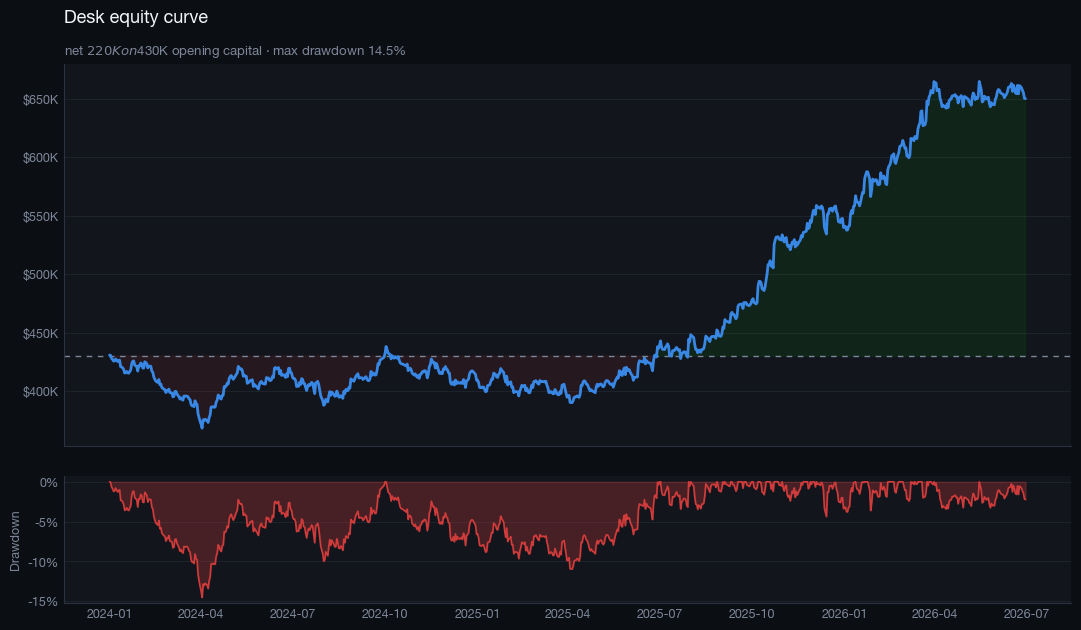

In [9]:
# --- 6.1 Equity curve with drawdown ------------------------------------
fig, (ax, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True,
                              gridspec_kw={"height_ratios": [3, 1], "hspace": 0.12})

ax.plot(equity.index, equity.values, color=T.CATEGORICAL[0], lw=2, zorder=3)
ax.fill_between(equity.index, STARTING_CAPITAL, equity.values,
                where=equity.values >= STARTING_CAPITAL, color=T.PROFIT, alpha=.10)
ax.fill_between(equity.index, STARTING_CAPITAL, equity.values,
                where=equity.values < STARTING_CAPITAL, color=T.LOSS, alpha=.10)
ax.axhline(STARTING_CAPITAL, color=T.TEXT_MUTED, lw=1, ls=(0, (4, 4)))
ax.yaxis.set_major_formatter(lambda v, _: T.money(v))
T.style_axes(ax); T.title(ax, "Desk equity curve",
                          f"net {T.money(net_pnl)} on {T.money(STARTING_CAPITAL)} "
                          f"opening capital · max drawdown {max_dd_pct:.1f}%")

ax2.fill_between(dd_pct.index, 0, dd_pct.values, color=T.LOSS, alpha=.28)
ax2.plot(dd_pct.index, dd_pct.values, color=T.LOSS, lw=1.2)
ax2.yaxis.set_major_formatter(lambda v, _: f"{v:.0f}%")
ax2.set_ylabel("Drawdown", color=T.TEXT_MUTED, fontsize=9)
T.style_axes(ax2)
plt.show()

The shape of this curve is the most important caveat in the whole project: the
sharp improvement from mid-2025 is **not** the desk getting better. It is
**survivorship** — the losing traders blow their accounts and stop trading, so
the surviving cohort is progressively more skewed toward the profitable ones.
Section 7 quantifies it. Any performance review that quotes the desk trend
without the active-trader count beside it is rewarding attrition.

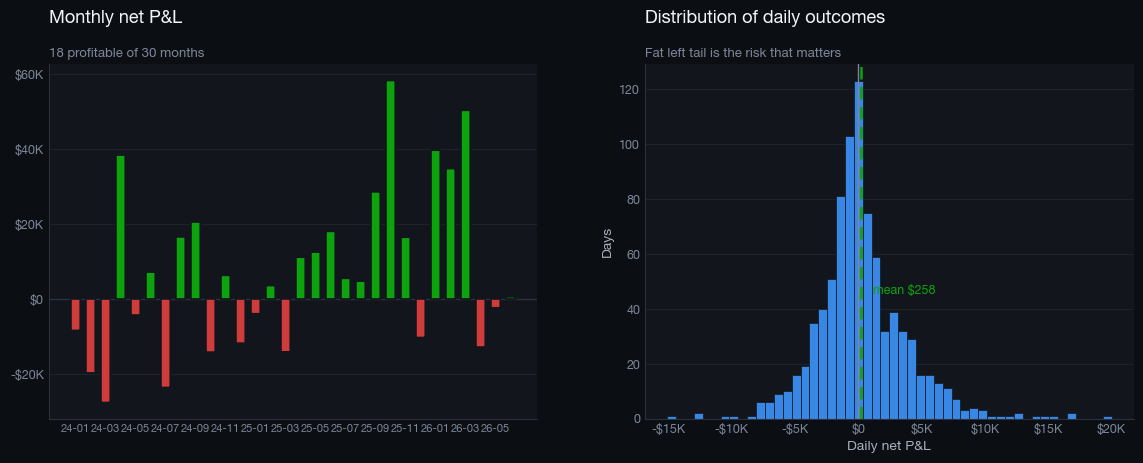

In [10]:
# --- 6.2 Monthly P&L and the distribution of daily outcomes -------------
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(14, 4.6), gridspec_kw={"wspace": .22})

m = df.groupby("year_month")["net_profit"].sum()
x = np.arange(len(m))
T.rounded_bars(ax, x, m.values, T.pnl_colors(m.values), width=.62)
ax.set_xticks(x[::2]); ax.set_xticklabels([i[2:] for i in m.index][::2], fontsize=8)
ax.axhline(0, color=T.AXIS, lw=1); ax.yaxis.set_major_formatter(lambda v, _: T.money(v))
T.style_axes(ax); T.title(ax, "Monthly net P&L",
                          f"{int((m > 0).sum())} profitable of {len(m)} months")

daily_pnl = df.groupby("trade_date")["net_profit"].sum()
ax2.hist(daily_pnl, bins=50, color=T.CATEGORICAL[0], edgecolor=T.SURFACE, lw=.5)
ax2.axvline(0, color=T.TEXT_MUTED, lw=1)
ax2.axvline(daily_pnl.mean(), color=T.PROFIT, lw=1.8, ls=(0, (5, 3)))
ax2.annotate(f"mean {T.money(daily_pnl.mean())}", xy=(daily_pnl.mean(), 0),
             xytext=(8, 90), textcoords="offset points", color=T.PROFIT, fontsize=9)
ax2.xaxis.set_major_formatter(lambda v, _: T.money(v))
ax2.set_xlabel("Daily net P&L"); ax2.set_ylabel("Days")
T.style_axes(ax2); T.title(ax2, "Distribution of daily outcomes",
                           "Fat left tail is the risk that matters")
plt.show()

In [11]:
# --- 6.3 Strategy scorecard ---------------------------------------------
# Ranked on expectancy in R. Ranking on dollars would just reward whichever
# strategy happened to be sized largest.
scorecard = (df.groupby("strategy")
             .agg(trades=("trade_id", "size"),
                  win_rate=("is_win", lambda s: s.mean() * 100),
                  avg_planned_rr=("risk_reward_ratio", "mean"),
                  expectancy_r=("r_multiple", "mean"),
                  gross=("profit_loss", "sum"),
                  fees=("fees", "sum"),
                  net=("net_profit", "sum"),
                  fee_pct_of_risk=("fee_pct_of_risk", "mean"))
             .sort_values("expectancy_r", ascending=False))
scorecard["breakeven_wr"] = 100 / (1 + scorecard["avg_planned_rr"])
scorecard["edge_pp"] = scorecard["win_rate"] - scorecard["breakeven_wr"]
scorecard.round(3)

,trades,win_rate,avg_planned_rr,expectancy_r,gross,fees,net,fee_pct_of_risk,breakeven_wr,edge_pp
strategy,,,,,,,,,,
Trend Following,1933,30.0050,3.0960,0.1490,"196,299.9900","29,045.7500","167,254.2400",3.1780,24.4120,5.5940
Swing,1117,23.9930,3.7770,0.0560,"28,592.9500","11,645.6300","16,947.3200",2.0640,20.9350,3.0580
Mean Reversion,1734,45.5020,1.4190,0.0400,"117,120.9400","31,717.2000","85,403.7400",3.8010,41.3440,4.1580
Breakout,2079,30.3990,2.5130,0.0020,"117,467.0200","41,176.2200","76,290.8000",4.1940,28.4640,1.9360
Order Block (SMC),849,28.5040,2.7890,-0.0030,"22,497.2100","17,644.1900","4,853.0200",4.6180,26.3910,2.1140
News Trading,1006,27.8330,2.4870,-0.1090,"-10,451.8500","14,284.8000","-24,736.6500",3.0900,28.6780,-0.8450
Scalping,2063,48.2790,1.0940,-0.1260,"15,024.5900","120,853.0700","-105,828.4800",11.7240,47.7580,0.5210


`Scalping` is the finding that justifies the whole exercise: it is **gross
positive and net negative**. The strategy is not losing to the market, it is
losing to transaction costs — its fee bill is roughly 3× every other strategy as
a share of the amount risked, because tight stops require a large notional per
unit of risk and fees scale with notional.

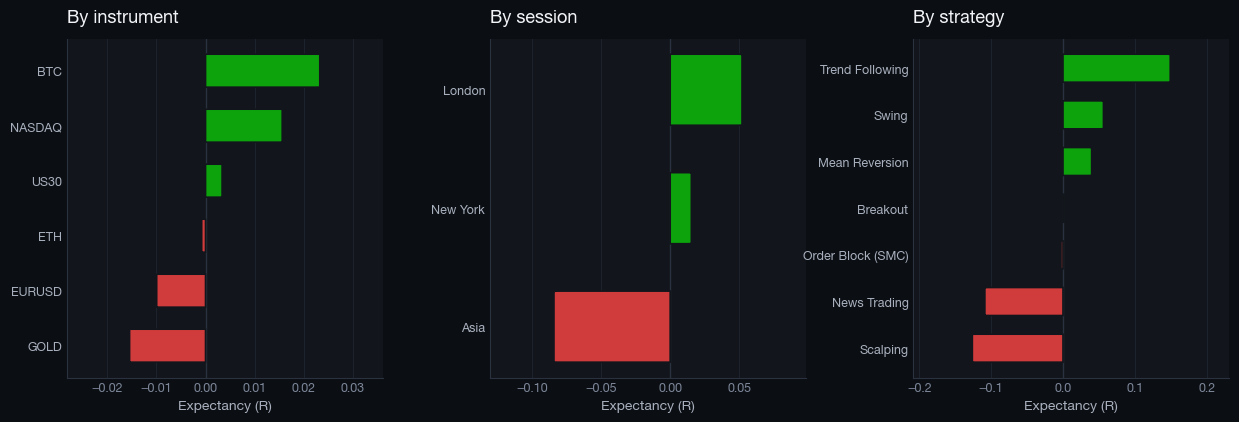

In [12]:
# --- 6.4 Asset, session and strategy performance ------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4), gridspec_kw={"wspace": .34})

for ax, (dim, label) in zip(axes, [("asset", "instrument"),
                                   ("trading_session", "session"),
                                   ("strategy", "strategy")]):
    g = df.groupby(dim)["r_multiple"].mean().sort_values()
    y = np.arange(len(g))
    T.rounded_bars(ax, y, g.values, T.pnl_colors(g.values), width=.6, horizontal=True)
    ax.set_yticks(y); ax.set_yticklabels(g.index, fontsize=9, color=T.TEXT_SECONDARY)
    ax.axvline(0, color=T.AXIS, lw=1)
    ax.set_xlabel("Expectancy (R)")
    pad = max(abs(g.min()), abs(g.max())) * .55
    ax.set_xlim(g.min() - pad, g.max() + pad)
    T.style_axes(ax, xgrid=True, ygrid=False)
    T.title(ax, f"By {label}")
plt.show()

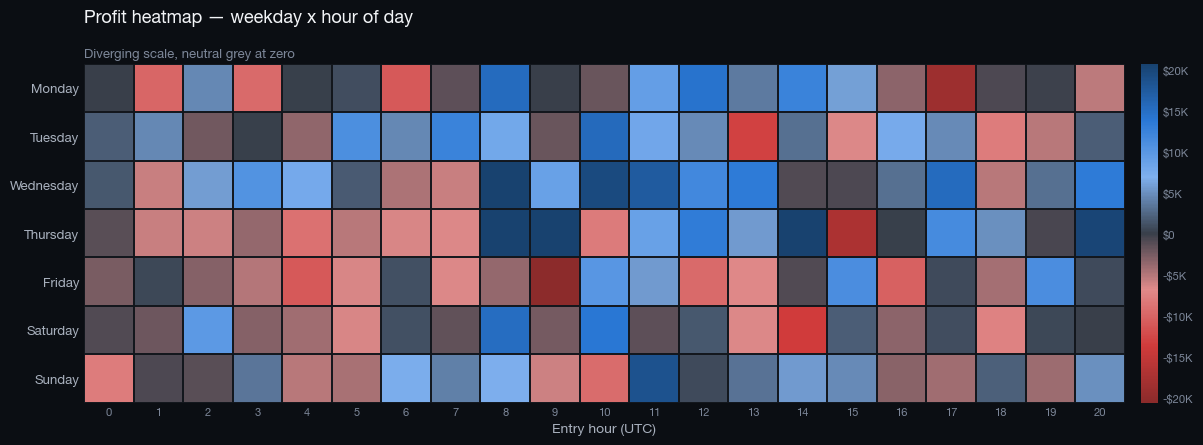

In [13]:
# --- 6.5 Profit heatmap: weekday x hour ---------------------------------
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
pivot = (df.pivot_table(index="weekday", columns="entry_hour",
                        values="net_profit", aggfunc="sum")
         .reindex(order).fillna(0))

fig, ax = plt.subplots(figsize=(14, 4.4))
# Clip at the 97.5th percentile so a couple of extreme cells cannot flatten
# every other cell into the neutral midpoint.
lim = np.percentile(np.abs(pivot.values), 97.5)
im = ax.imshow(pivot.values, cmap=T.CMAP_DIV, vmin=-lim, vmax=lim, aspect="auto")
ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns, fontsize=8)
ax.set_yticks(range(len(order))); ax.set_yticklabels(order, fontsize=9.5,
                                                     color=T.TEXT_SECONDARY)
ax.set_xlabel("Entry hour (UTC)"); ax.grid(False)
for s in ax.spines.values():
    s.set_visible(False)
ax.set_xticks(np.arange(-.5, len(pivot.columns), 1), minor=True)
ax.set_yticks(np.arange(-.5, len(order), 1), minor=True)
ax.grid(which="minor", color=T.SURFACE, lw=1.4); ax.tick_params(which="minor", length=0)
cb = fig.colorbar(im, ax=ax, pad=.015, fraction=.026)
cb.ax.yaxis.set_major_formatter(lambda v, _: T.money(v))
cb.ax.tick_params(colors=T.TEXT_MUTED, labelsize=8, length=0); cb.outline.set_visible(False)
T.title(ax, "Profit heatmap — weekday x hour of day",
        "Diverging scale, neutral grey at zero")
plt.show()

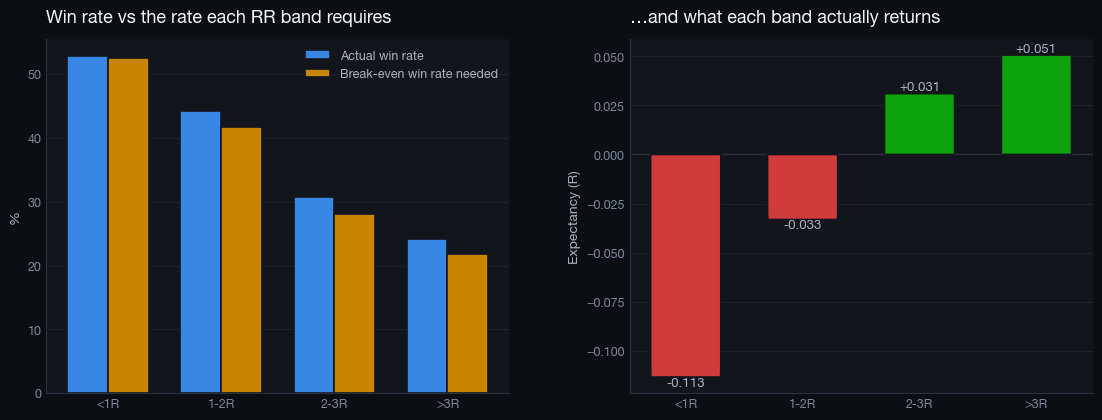

,trades,actual_wr,avg_rr,expectancy_r,net,breakeven_wr,edge_pp
rr_bucket,,,,,,,
<1R,726,52.8930,0.9030,-0.1130,"-40,724.3500",52.5530,0.3390
1-2R,3618,44.3060,1.3990,-0.0330,"36,789.0600",41.6840,2.6220
2-3R,3665,30.8320,2.5510,0.0310,"178,285.7100",28.1580,2.6750
>3R,2772,24.1700,3.5890,0.0510,"45,833.5700",21.7930,2.3770


In [14]:
# --- 6.6 The reward:risk paradox ----------------------------------------
rr = (df.groupby("rr_bucket")
      .agg(trades=("trade_id", "size"),
           actual_wr=("is_win", lambda s: s.mean() * 100),
           avg_rr=("risk_reward_ratio", "mean"),
           expectancy_r=("r_multiple", "mean"),
           net=("net_profit", "sum")))
rr["breakeven_wr"] = 100 / (1 + rr["avg_rr"])
rr["edge_pp"] = rr["actual_wr"] - rr["breakeven_wr"]
rr = rr.sort_values("avg_rr")

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(13.5, 4.6), gridspec_kw={"wspace": .26})
x = np.arange(len(rr)); w = .36
ax.bar(x - w/2, rr["actual_wr"], w, color=T.CATEGORICAL[0], label="Actual win rate",
       edgecolor=T.SURFACE, lw=1.2)
ax.bar(x + w/2, rr["breakeven_wr"], w, color=T.CATEGORICAL[3],
       label="Break-even win rate needed", edgecolor=T.SURFACE, lw=1.2)
ax.set_xticks(x); ax.set_xticklabels(rr.index); ax.set_ylabel("%")
ax.legend(loc="upper right"); T.style_axes(ax)
T.title(ax, "Win rate vs the rate each RR band requires")

T.rounded_bars(ax2, x, rr["expectancy_r"].values,
               T.pnl_colors(rr["expectancy_r"].values), width=.6)
ax2.set_xticks(x); ax2.set_xticklabels(rr.index)
ax2.axhline(0, color=T.AXIS, lw=1); ax2.set_ylabel("Expectancy (R)")
for i, v in enumerate(rr["expectancy_r"].values):
    ax2.text(i, v, f"{v:+.3f}", ha="center", va="bottom" if v >= 0 else "top",
             fontsize=9.5, color=T.TEXT_SECONDARY)
T.style_axes(ax2); T.title(ax2, "…and what each band actually returns")
plt.show()
rr.round(3)

**Every RR band beats its own break-even rate by 2–3 percentage points** — the
raw edge is remarkably consistent. Yet only the 2R+ bands are actually
profitable. Fees are a roughly *fixed* cost per trade, so they consume a far
larger share of a small 1R target than of a 3R one.

The practical conclusion is counter-intuitive and important: **a high win rate is
a warning sign, not a goal.** The `<1R` band wins 53% of the time and still loses
money.

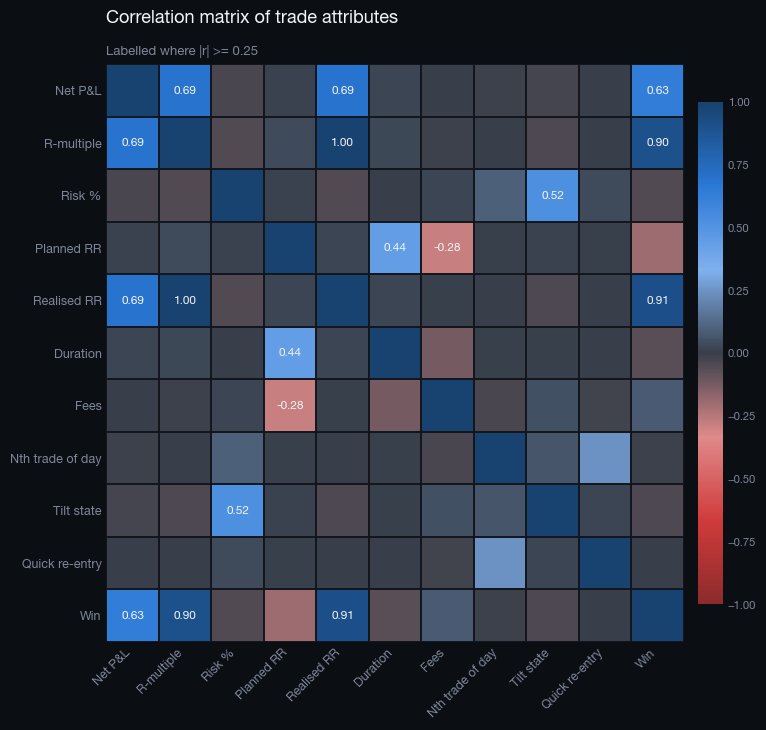

In [15]:
# --- 6.7 Correlation matrix ---------------------------------------------
cols = {"net_profit": "Net P&L", "r_multiple": "R-multiple", "risk_pct": "Risk %",
        "risk_reward_ratio": "Planned RR", "realised_rr": "Realised RR",
        "trade_duration_min": "Duration", "fees": "Fees",
        "trade_seq_in_day": "Nth trade of day", "is_tilt_state": "Tilt state",
        "is_quick_reentry": "Quick re-entry", "is_win": "Win"}
corr = df[list(cols)].corr().rename(index=cols, columns=cols)

fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(corr.values, cmap=T.CMAP_DIV, vmin=-1, vmax=1)
n_ = len(corr)
ax.set_xticks(range(n_)); ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(n_)); ax.set_yticklabels(corr.index, fontsize=9)
ax.grid(False)
for s in ax.spines.values():
    s.set_visible(False)
ax.set_xticks(np.arange(-.5, n_, 1), minor=True); ax.set_yticks(np.arange(-.5, n_, 1), minor=True)
ax.grid(which="minor", color=T.SURFACE, lw=1.4); ax.tick_params(which="minor", length=0)
# Label only the meaningful cells — a number in every cell is unreadable.
for i in range(n_):
    for j in range(n_):
        v = corr.values[i, j]
        if i != j and abs(v) >= .25:
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8.5,
                    color=T.TEXT_PRIMARY, fontweight="600")
cb = fig.colorbar(im, ax=ax, pad=.02, fraction=.036)
cb.ax.tick_params(colors=T.TEXT_MUTED, labelsize=8, length=0); cb.outline.set_visible(False)
T.title(ax, "Correlation matrix of trade attributes", "Labelled where |r| >= 0.25")
plt.show()

## 7. Trading psychology

The behavioural columns are what make a trading *journal* more valuable than a
broker statement. This is where the largest single effect in the dataset lives.

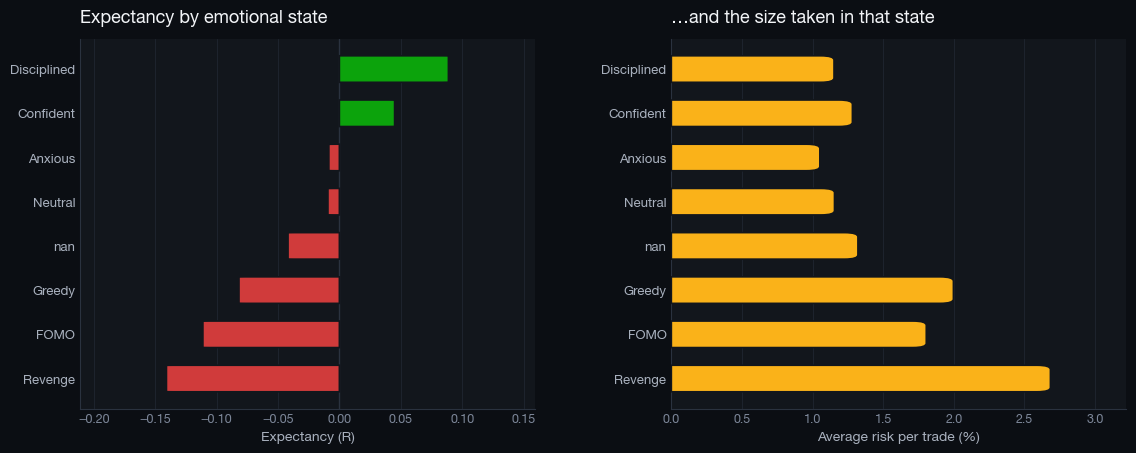

,trades,win_rate,avg_risk_pct,expectancy_r,net
emotional_state,,,,,
Revenge,694,28.5300,2.6840,-0.1410,"-41,562.5200"
FOMO,884,31.4480,1.8050,-0.1110,"-38,618.7700"
Greedy,416,32.9330,1.9970,-0.0820,"1,518.1800"
nan,257,33.0740,1.3210,-0.0420,"-5,072.6700"
Neutral,2474,34.6000,1.1550,-0.0090,"19,638.8300"
Anxious,1239,33.9790,1.0520,-0.0090,"29,536.6400"
Confident,2317,36.9440,1.2820,0.0450,"96,321.3300"
Disciplined,2500,38.2400,1.1520,0.0890,"158,422.9700"


In [16]:
psych = (df[df.emotional_state != "Unspecified"]
         .groupby("emotional_state")
         .agg(trades=("trade_id", "size"),
              win_rate=("is_win", lambda s: s.mean() * 100),
              avg_risk_pct=("risk_pct", "mean"),
              expectancy_r=("r_multiple", "mean"),
              net=("net_profit", "sum"))
         .sort_values("expectancy_r"))

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(13.5, 4.8), gridspec_kw={"wspace": .30})
y = np.arange(len(psych))
T.rounded_bars(ax, y, psych["expectancy_r"].values,
               T.pnl_colors(psych["expectancy_r"].values), width=.6, horizontal=True)
ax.set_yticks(y); ax.set_yticklabels(psych.index, fontsize=9.5, color=T.TEXT_SECONDARY)
ax.axvline(0, color=T.AXIS, lw=1); ax.set_xlabel("Expectancy (R)")
pad = max(abs(psych["expectancy_r"].min()), abs(psych["expectancy_r"].max())) * .5
ax.set_xlim(psych["expectancy_r"].min() - pad, psych["expectancy_r"].max() + pad)
T.style_axes(ax, xgrid=True, ygrid=False); T.title(ax, "Expectancy by emotional state")

T.rounded_bars(ax2, y, psych["avg_risk_pct"].values, [T.WARNING] * len(psych),
               width=.6, horizontal=True)
ax2.set_yticks(y); ax2.set_yticklabels(psych.index, fontsize=9.5, color=T.TEXT_SECONDARY)
ax2.set_xlabel("Average risk per trade (%)")
ax2.set_xlim(0, psych["avg_risk_pct"].max() * 1.2)
T.style_axes(ax2, xgrid=True, ygrid=False)
T.title(ax2, "…and the size taken in that state")
plt.show()
psych.round(3)

This is the headline behavioural finding, and it is a compounding one: the states
with the **worst** expectancy are also the states in which traders take the
**largest** positions. Revenge trades run at roughly 2.3× the position size of
disciplined trades while returning materially negative expectancy — the precise
mechanism by which accounts are destroyed rather than merely eroded.

In [17]:
# --- 7.1 The tilt spiral -------------------------------------------------
# Does risk rise as a losing streak lengthens?
tmp = df.copy()
tmp["prev_loss_streak"] = (tmp.groupby("trader_id")["is_win"]
                           .transform(lambda s: (1 - s).groupby((s != s.shift()).cumsum())
                                      .cumsum().shift(1).fillna(0)).clip(0, 5))
spiral = tmp.groupby("prev_loss_streak").agg(
    trades=("trade_id", "size"),
    avg_risk_pct=("risk_pct", "mean"),
    expectancy_r=("r_multiple", "mean"),
    win_rate=("is_win", lambda s: s.mean() * 100))
spiral.round(4)

,trades,avg_risk_pct,expectancy_r,win_rate
prev_loss_streak,,,,
0.0000,3795,1.3000,0.0230,35.8103
1.0000,2433,1.3448,0.0257,36.2926
2.0000,1549,1.3451,0.0006,34.9258
3.0000,1006,1.3859,0.0056,33.9960
4.0000,664,1.4414,-0.0336,34.6386
5.0000,1334,1.4998,-0.0616,32.3838


In [18]:
# --- 7.2 Overtrading and the disposition effect -------------------------
tmp["seq_bucket"] = pd.cut(tmp["trade_seq_in_day"], [0, 1, 3, 5, 8, 100],
                           labels=["1st", "2nd-3rd", "4th-5th", "6th-8th", "9th+"])
over = tmp.groupby("seq_bucket", observed=True).agg(
    trades=("trade_id", "size"),
    expectancy_r=("r_multiple", "mean"),
    avg_risk_pct=("risk_pct", "mean"))

hold = df.groupby("win_loss")["trade_duration_min"].agg(["mean", "median", "size"])
print("Overtrading — quality by position in the day's sequence:")
print(over.round(4).to_string())
print("\nDisposition effect — holding time by outcome:")
print(hold.round(1).to_string())
print(f"\nLosers are held {hold.loc['Loss', 'mean'] / hold.loc['Win', 'mean'] - 1:+.0%} "
      f"longer than winners.")

Overtrading — quality by position in the day's sequence:
            trades  expectancy_r  avg_risk_pct
seq_bucket                                    
1st           3651        0.0095        1.2922
2nd-3rd       4550        0.0116        1.3602
4th-5th       1891       -0.0191        1.4116
6th-8th        632        0.0198        1.4978
9th+            57       -0.2089        2.0743

Disposition effect — holding time by outcome:
             mean  median  size
win_loss                       
Loss     285.8000 62.0000  6994
Win      197.8000 42.0000  3787

Losers are held +45% longer than winners.


Two textbook biases, both measurable here:

- **Overtrading.** Trade quality decays through the session and collapses beyond
  the eighth trade of the day, while position size *increases*.
- **Disposition effect.** Losers are held substantially longer than winners —
  cutting winners early and hoping losers recover. A bracket order placed at
  entry removes the discretionary moment where this bias operates.

## 8. Machine learning — can we predict a winning trade?

**Binary classification: will this trade close profitably, using only what is
knowable at the moment of entry?**

Two design decisions decide whether this is a real model or a demo:

1. **Leakage control.** Most blotter columns are recorded when a trade *closes*
   (`net_profit`, `r_multiple`, duration, fees, running streaks and equity).
   Feeding any of them to the model yields ~99% accuracy and a worthless result.
   Only entry-time features are used.
2. **Chronological split.** Train on the first 80% of the timeline, test on the
   last 20%. A random split lets the model learn from the future.

In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

CAT = ["trader_id", "asset", "strategy", "trading_session", "trade_type",
       "emotional_state", "weekday", "risk_bucket", "rr_bucket"]
NUM = ["entry_hour", "weekday_num", "risk_pct", "risk_reward_ratio", "reward_pct",
       "trade_seq_in_day", "prev_result", "is_quick_reentry", "is_tilt_state",
       "minutes_since_prev_exit"]

# Everything recorded at or after the close is banned outright.
LEAKY = {"net_profit", "profit_loss", "fees", "r_multiple", "realised_rr",
         "exit_price", "trade_duration_min", "win_loss", "is_win",
         "gross_profit", "gross_loss", "account_balance", "fee_pct_of_risk"}
assert not LEAKY.intersection(CAT + NUM), "LEAKAGE: a post-close column reached the features"
print(f"Leakage check passed — {len(LEAKY)} post-close columns excluded")

X = df[CAT + NUM].copy()
X[NUM] = X[NUM].apply(pd.to_numeric, errors="coerce")
X[NUM] = X[NUM].fillna(X[NUM].median())
X[CAT] = X[CAT].astype(str)
y = df["is_win"]

cut = int(len(X) * .8)
X_tr, X_te, y_tr, y_te = X.iloc[:cut], X.iloc[cut:], y.iloc[:cut], y.iloc[cut:]
print(f"Chronological split at {df['entry_datetime'].iloc[cut]:%Y-%m-%d}: "
      f"{len(X_tr):,} train / {len(X_te):,} test")
print(f"Train win rate {y_tr.mean() * 100:.2f}% · test win rate {y_te.mean() * 100:.2f}%")

Leakage check passed — 13 post-close columns excluded
Chronological split at 2025-11-20: 8,624 train / 2,157 test
Train win rate 34.79% · test win rate 36.49%


In [20]:
pipe = Pipeline([
    ("pre", ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=25), CAT),
        ("num", "passthrough", NUM)])),
    ("model", RandomForestClassifier(n_estimators=400, max_depth=12,
                                     min_samples_leaf=25, max_features="sqrt",
                                     class_weight="balanced_subsample",
                                     random_state=42, n_jobs=-1))])
pipe.fit(X_tr, y_tr)

pred  = pipe.predict(X_te)
proba = pipe.predict_proba(X_te)[:, 1]
majority = max(y_te.mean(), 1 - y_te.mean())

print(f"Accuracy           : {accuracy_score(y_te, pred):.4f}")
print(f"Majority baseline  : {majority:.4f}   <-- always predicting 'Loss'")
print(f"ROC-AUC            : {roc_auc_score(y_te, proba):.4f}   (0.5 = coin flip)")
print()
print(classification_report(y_te, pred, target_names=["Loss", "Win"]))

Accuracy           : 0.6069
Majority baseline  : 0.6351   <-- always predicting 'Loss'
ROC-AUC            : 0.6106   (0.5 = coin flip)

              precision    recall  f1-score   support

        Loss       0.71      0.65      0.68      1370
         Win       0.47      0.53      0.50       787

    accuracy                           0.61      2157
   macro avg       0.59      0.59      0.59      2157
weighted avg       0.62      0.61      0.61      2157



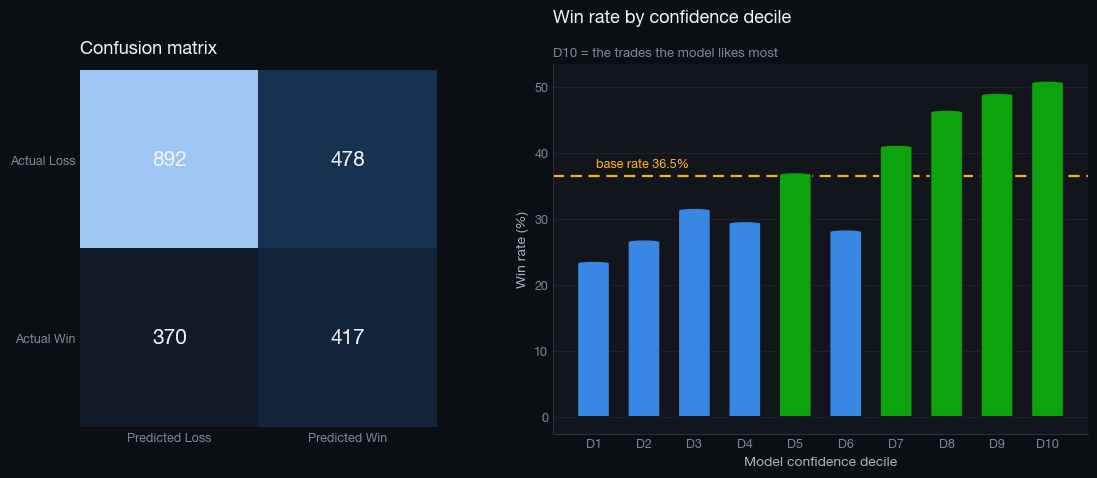

,win_rate,expectancy_r
decile,,
D1,0.2361,0.1059
D2,0.2685,0.0472
D3,0.3163,0.1476
D4,0.2963,0.0419
D5,0.3704,0.2253
D6,0.2837,-0.0797
D7,0.4120,-0.0033
D8,0.4651,-0.0128
D9,0.4907,-0.0055


In [21]:
# --- 8.1 Confusion matrix and decile lift -------------------------------
cm = confusion_matrix(y_te, pred)
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(13, 4.8),
                              gridspec_kw={"width_ratios": [1, 1.5], "wspace": .26})

ax.imshow(cm / cm.sum() * 100, cmap=T.CMAP_SEQ)
ax.set_xticks([0, 1]); ax.set_xticklabels(["Predicted Loss", "Predicted Win"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["Actual Loss", "Actual Win"])
ax.grid(False)
for s in ax.spines.values():
    s.set_visible(False)
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center", fontsize=15,
                fontweight="600", color=T.TEXT_PRIMARY)
T.title(ax, "Confusion matrix")

lift = pd.DataFrame({"proba": proba, "win": y_te.to_numpy(),
                     "r": df["r_multiple"].iloc[cut:].to_numpy()})
lift["decile"] = pd.qcut(lift["proba"].rank(method="first"), 10,
                         labels=[f"D{i}" for i in range(1, 11)])
dec = lift.groupby("decile", observed=True).agg(win_rate=("win", "mean"),
                                                expectancy_r=("r", "mean"))
xd = np.arange(len(dec))
T.rounded_bars(ax2, xd, dec["win_rate"].values * 100,
               [T.PROFIT if v > y_te.mean() else T.CATEGORICAL[0]
                for v in dec["win_rate"]], width=.64)
ax2.axhline(y_te.mean() * 100, color=T.WARNING, lw=1.6, ls=(0, (5, 3)))
ax2.annotate(f"base rate {y_te.mean() * 100:.1f}%", xy=(0, y_te.mean() * 100),
             xytext=(2, 6), textcoords="offset points", color=T.WARNING,
             fontsize=9, fontweight="600")
ax2.set_xticks(xd); ax2.set_xticklabels(dec.index)
ax2.set_ylabel("Win rate (%)"); ax2.set_xlabel("Model confidence decile")
T.style_axes(ax2); T.title(ax2, "Win rate by confidence decile",
                           "D10 = the trades the model likes most")
plt.show()
dec.round(4)

### Reading this honestly

Accuracy is the wrong headline. Only ~36% of hold-out trades are winners, so a
model that predicts "Loss" every time scores ~64% accuracy while being useless.
The measures that matter are **ROC-AUC** (~0.62 — modest but genuinely better
than chance) and whether the flagged trades actually earn more.

And here is the honest limitation. **Win rate rises cleanly across the confidence
deciles, but expectancy in R does not.** That is not a broken model — it is the
model correctly learning the identity proved in section 6.6: a near-1:1 target
hits far more often *and is worth far less when it does*. Ranking trades by
probability of winning therefore preferentially selects low-RR trades, whose
expectancy is poor once fees are paid.

**Consequence:** this classifier should not be deployed as a trade filter on its
own. The correct target is expected R — a regression on `r_multiple` — which is
the first item in Future Improvements. The distinction between a model that looks
good on a slide and one that makes money is exactly this.

The features that carry the signal are **behavioural and structural, not
predictive of the market**: planned reward:risk, trader identity, emotional state
and session. That is the correct result for a trading journal — the edge lives in
execution discipline, not in forecasting price. A blotter model that appeared to
forecast the market would be a leakage bug, not a discovery.

## 9. Export and conclusions

In [22]:
out = os.path.abspath(os.path.join("..", "data", "processed", "trades_clean_notebook.csv"))
df.to_csv(out, index=False)
print(f"Exported {len(df):,} clean trades x {df.shape[1]} columns")
print(f"  -> {out}")

Exported 10,781 clean trades x 52 columns
  -> /Users/ankitmaholiya/Documents/Ankit/projects/trading journal copy/TradeTrack-Analytics/data/processed/trades_clean_notebook.csv


---

## Conclusions

**The desk is marginally profitable and the edge is fragile.** Net
\$220K on \$430K of opening capital, profit factor 1.07, Sharpe 0.80. That is a
real but thin result, and the priority is removing the identified loss centres
rather than adding size.

### The five findings that matter

1. **Fees consume more than half of gross profit.** The single largest and most
   certain lever available, and it requires no forecasting skill.
2. **Scalping is gross-positive and net-negative.** It loses to transaction
   costs, not to the market — its fee burden is ~3× every other strategy as a
   share of risk.
3. **Revenge trading is the most destructive measurable behaviour.** Worst
   expectancy combined with ~2.3× the position size — the exact mechanism of
   account destruction. A mandatory lockout after two consecutive losses is the
   highest-value control on the desk.
4. **A high win rate is a warning sign, not a goal.** The `<1R` band wins 53% of
   the time and still loses money.
5. **The improving equity curve is survivorship.** Four of twelve accounts blew
   up; the trend must always be quoted with the active-trader count beside it.

### What I would do next

- Re-target the ML model on **expected R** rather than win probability — the
  current objective provably selects the wrong trades.
- Add walk-forward validation with an expanding window instead of a single split.
- Model fees explicitly per venue to quantify the commission-renegotiation case.
- Bring in market-regime context (volatility, trend state) to test whether
  strategy edges are conditional on regime.